1. Cargar `data/life_expectancy.csv` con `index_col='CountryYear'`.
2. Quitar las columnas `Life expectancy` (target) y `Status`. Aplicar `.dropna()`.
3. Definir X (todas las restantes) y `y = Life expectancy`.
4. Train/test split 80/20, random_state=7.
5. Estandarizar correctamente.
6. Entrenar `LinearRegression`.
7. Reportar MAE, RMSE y R². ¿Es un buen modelo?
8. **Bonus:** ¿Cuál es la variable con mayor coeficiente (en valor absoluto)? Eso indica cuál es la más influyente.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
df = pd.read_csv('Data/life_expectancy.csv', index_col='CountryYear')

In [11]:
print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

Primeras filas del DataFrame:


,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
CountryYear,,,,,,,,,,,,,,,,,,,,
Afghanistan2015,0,65.0,263,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
Afghanistan2014,0,59.9,271,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
Afghanistan2013,0,59.9,268,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
Afghanistan2012,0,59.5,272,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
Afghanistan2011,0,59.2,275,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
Afghanistan2010,0,58.8,279,74,0.01,79.679367,66.0,1989,16.7,102,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
Afghanistan2009,0,58.6,281,77,0.01,56.762217,63.0,2861,16.2,106,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
Afghanistan2008,0,58.1,287,80,0.03,25.873925,64.0,1599,15.7,110,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
Afghanistan2007,0,57.5,295,82,0.02,10.910156,63.0,1141,15.2,113,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4


Ultimas filas del DataFrame:
              Status  Life expectancy  Adult Mortality  infant deaths  \
CountryYear                                                             
Zimbabwe2004       0             44.3              723             27   
Zimbabwe2003       0             44.5              715             26   
Zimbabwe2002       0             44.8               73             25   
Zimbabwe2001       0             45.3              686             25   
Zimbabwe2000       0             46.0              665             24   

              Alcohol  percentage expenditure  Hepatitis B  Measles   BMI  \
CountryYear                                                                 
Zimbabwe2004     4.36                     0.0         68.0       31  27.1   
Zimbabwe2003     4.06                     0.0          7.0      998  26.7   
Zimbabwe2002     4.43                     0.0         73.0      304  26.3   
Zimbabwe2001     1.72                     0.0         76.0      529  25.9 

In [12]:
print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

Estadisticas descriptivas del DataFrame:
       Status  Life expectancy  Adult Mortality  infant deaths      Alcohol  \
count  2928.0      2928.000000      2928.000000    2928.000000  2735.000000   
mean      0.0        69.224932       164.796448      30.407445     4.614856   
std       0.0         9.523867       124.292079     118.114450     4.050749   
min       0.0        36.300000         1.000000       0.000000     0.010000   
25%       0.0        63.100000        74.000000       0.000000     0.905000   
50%       0.0        72.100000       144.000000       3.000000     3.770000   
75%       0.0        75.700000       228.000000      22.000000     7.715000   
max       0.0        89.000000       723.000000    1800.000000    17.870000   

       percentage expenditure  Hepatitis B        Measles          BMI  \
count             2928.000000  2375.000000    2928.000000  2896.000000   
mean               740.321185    80.960842    2427.855874    38.235394   
std               1990.93

In [13]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
Status                               int64
Life expectancy                    float64
Adult Mortality                      int64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object


In [6]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


In [14]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
Status                               0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                            193
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 32
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                443
Population                         644
thinness  1-19 years                32
thinness 5-9 years                  32
Income composition of resources    160
Schooling                          160
dtype: int64


In [16]:
df = df.dropna()

In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
X = df.drop(columns=['Life expectancy', 'Status'])
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc =  scaler.transform(X_test)

modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)
y_pred = modelo.predict(X_test_esc)

print(f'Pendientes aprendidas: {modelo.coef_.round(2)}')
print(f'Intercepto:            {modelo.intercept_:,.2f}')



Pendientes aprendidas: [ -2.13  11.06  -0.16   0.52  -0.14  -0.08   0.75 -11.16   0.21   0.2
   0.32  -2.67   0.29  -0.07   0.1   -0.3    1.77   2.39]
Intercepto:            69.21


In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE:   {mae:.2f} años')
print(f'MSE:   {mse:.2f} años')
print(f'RMSE:  {rmse:.2f} años')
print(f'R²:    {r2:.4f} varianza explicada')

MAE:   2.67 años
MSE:   12.63 años
RMSE:  3.55 años
R²:    0.8336 varianza explicada


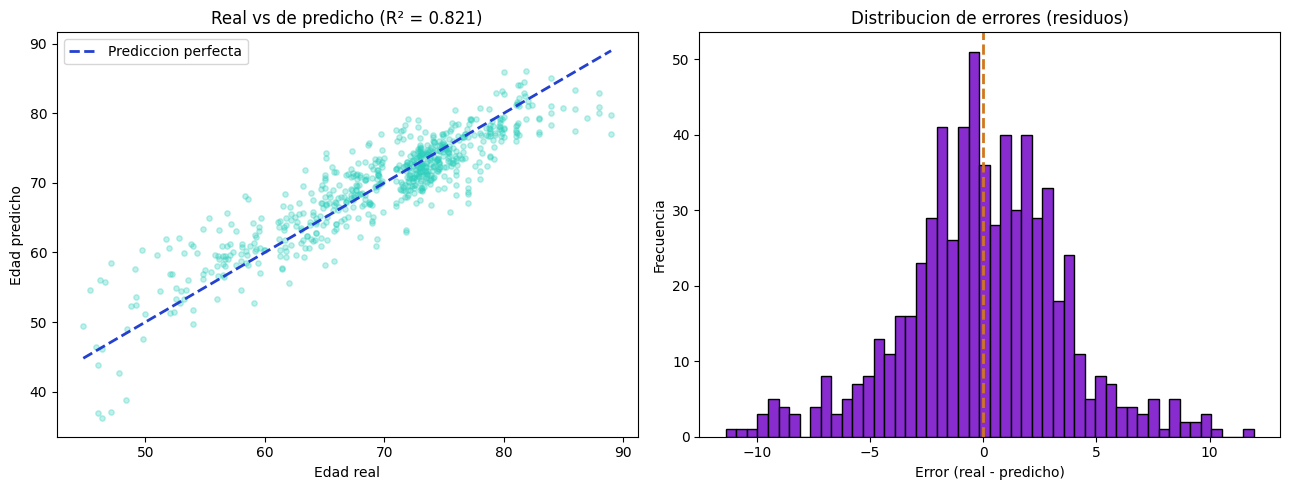

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=15, color='#2BCFBC')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="#2440CE", linewidth=2, linestyle='--', label='Prediccion perfecta')
axes[0].set_xlabel('Edad real')
axes[0].set_ylabel('Edad predicho')
axes[0].set_title(f'Real vs de predicho (R² = {r2:.3f})')
axes[0].legend()

residuos = y_test - y_pred
axes[1].hist(residuos, bins=50, color='#882BCF', edgecolor='black')
axes[1].axvline(0, color="#D0771E", linewidth=2, linestyle='--')
axes[1].set_title('Distribucion de errores (residuos)')
axes[1].set_xlabel('Error (real - predicho)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()



In [21]:
X = df.drop(columns=['Life expectancy', 'Status'])
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc =  scaler.transform(X_test)

modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)
y_pred = modelo.predict(X_test_esc)

print(f'Pendientes aprendidas: {modelo.coef_.round(2)}')
print(f'Intercepto:            {modelo.intercept_:,.2f}')

Pendientes aprendidas: [ -2.2   10.46  -0.17   0.53  -0.14  -0.03   0.68 -10.62   0.18   0.2
   0.25  -2.7    0.25  -0.05  -0.04  -0.16   1.88   2.38]
Intercepto:            69.17


In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE:   {mae:.2f} años')
print(f'MSE:   {mse:.2f} años')
print(f'RMSE:  {rmse:.2f} años')
print(f'R²:    {r2:.4f} varianza explicada')

MAE:   2.70 años
MSE:   12.64 años
RMSE:  3.55 años
R²:    0.8248 varianza explicada


In [23]:
X = df.drop(columns=['Life expectancy', 'Status'])
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=7)

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc =  scaler.transform(X_test)

modelo = LinearRegression()
modelo.fit(X_train_esc, y_train)
y_pred = modelo.predict(X_test_esc)

print(f'Pendientes aprendidas: {modelo.coef_.round(2)}')
print(f'Intercepto:            {modelo.intercept_:,.2f}')

Pendientes aprendidas: [-2.31  9.56 -0.14  0.55 -0.14 -0.05  0.67 -9.74  0.22  0.23  0.23 -2.64
  0.27 -0.05 -0.04 -0.2   1.89  2.32]
Intercepto:            69.08


In [24]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE:   {mae:.2f} años')
print(f'MSE:   {mse:.2f} años')
print(f'RMSE:  {rmse:.2f} años')
print(f'R²:    {r2:.4f} varianza explicada')

MAE:   2.71 años
MSE:   12.66 años
RMSE:  3.56 años
R²:    0.8213 varianza explicada
